# Run infection dynamics with monoclonal killer T cell response

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

In [2]:
# Run single simulation
N_0 = 100
#d_I = 2*d_S
infection_type = "prim" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"
reg = np.array([1.0, -1.0, 1.0, 1.0, -1.0, -1.0])

# %timeit -n 2 -r 2
regs, dyn, ts, lin_comp, p_diff, Eff, mycNa, myccM, mycEin, mycEout = agent_stoch_sim(N_0 = N_0, b_I = b_I, K_IE = 78000,
                                                                                      d_I = 10*d_S,
                                                                                      regulation_coeffs =  reg,
                                                                                      infection = infection_type,
                                                                                      vir_model = "dep_harm",
                                                                                      reg_model = np.array(["hill_or", "hill_and", "hill_or"]))

S, I, A, N, E, cM, eM, H, I_d_I, I_d_S = dyn[:,-10], dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

In [3]:
reg_string = '-'.join((reg * 1).astype('U1'))

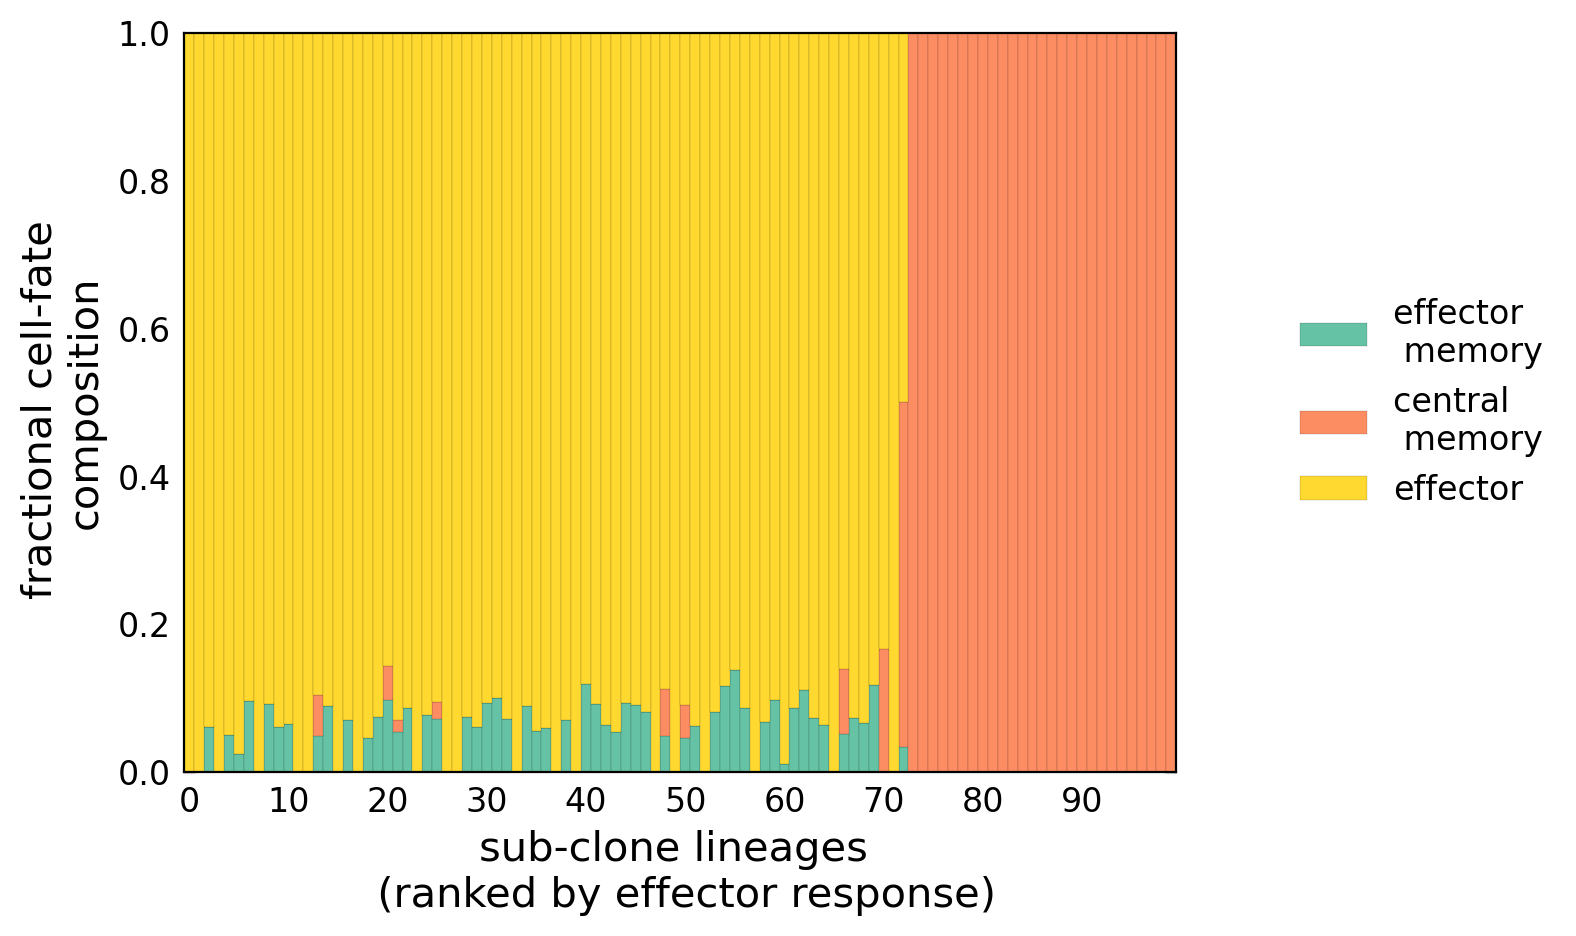

In [4]:
keys = np.array(['naive', 'central \n memory', 'effector', 'effector \n memory'])[1:]
all_counts = lin_comp[1:-2].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.05,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, N_0, 10))
ax.set_xticklabels(ax.get_xticks(), fontsize=12)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_type+'-'+'fates-by-lin-'+reg_string+'.png', dpi=300, bbox_inches="tight")


0.12958494134874995


7695

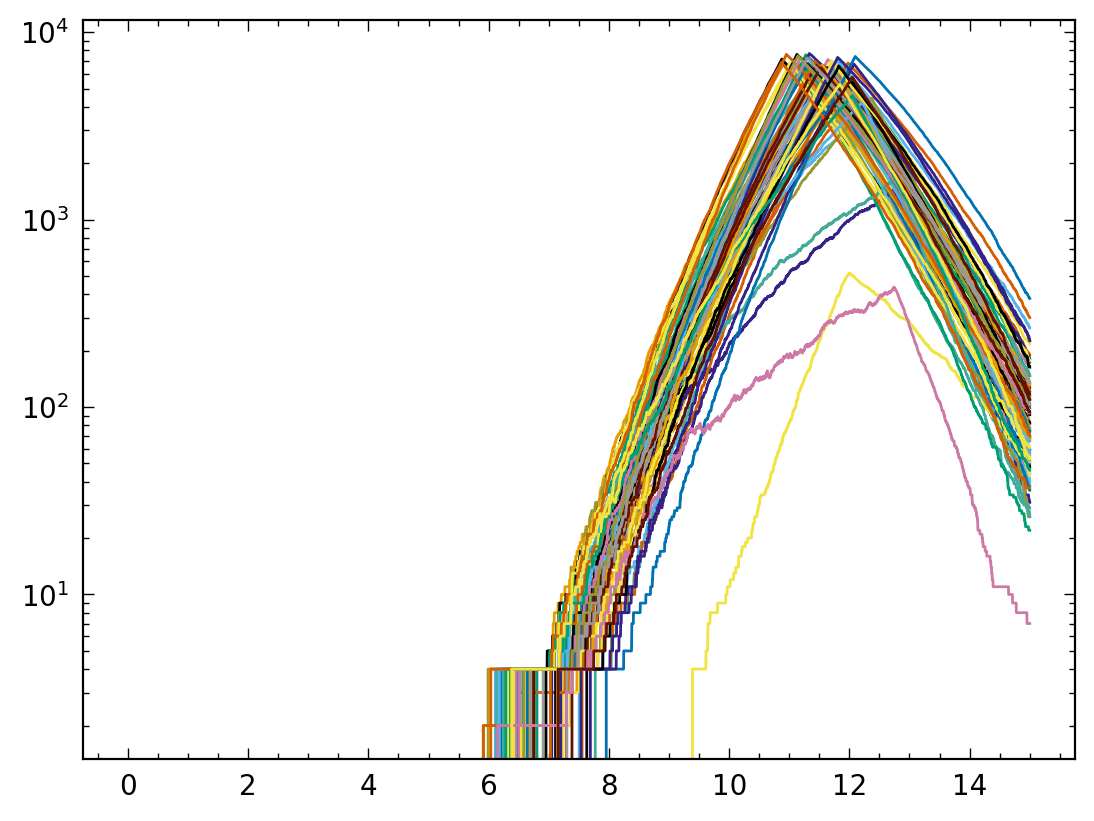

In [5]:
print(np.amax(cM + eM)/np.amax(E))
#print(E[np.argmax(E):np.argmax(E)+500])
plt.plot(ts, Eff)
plt.semilogy()
np.max(Eff)

1820.8122613288947


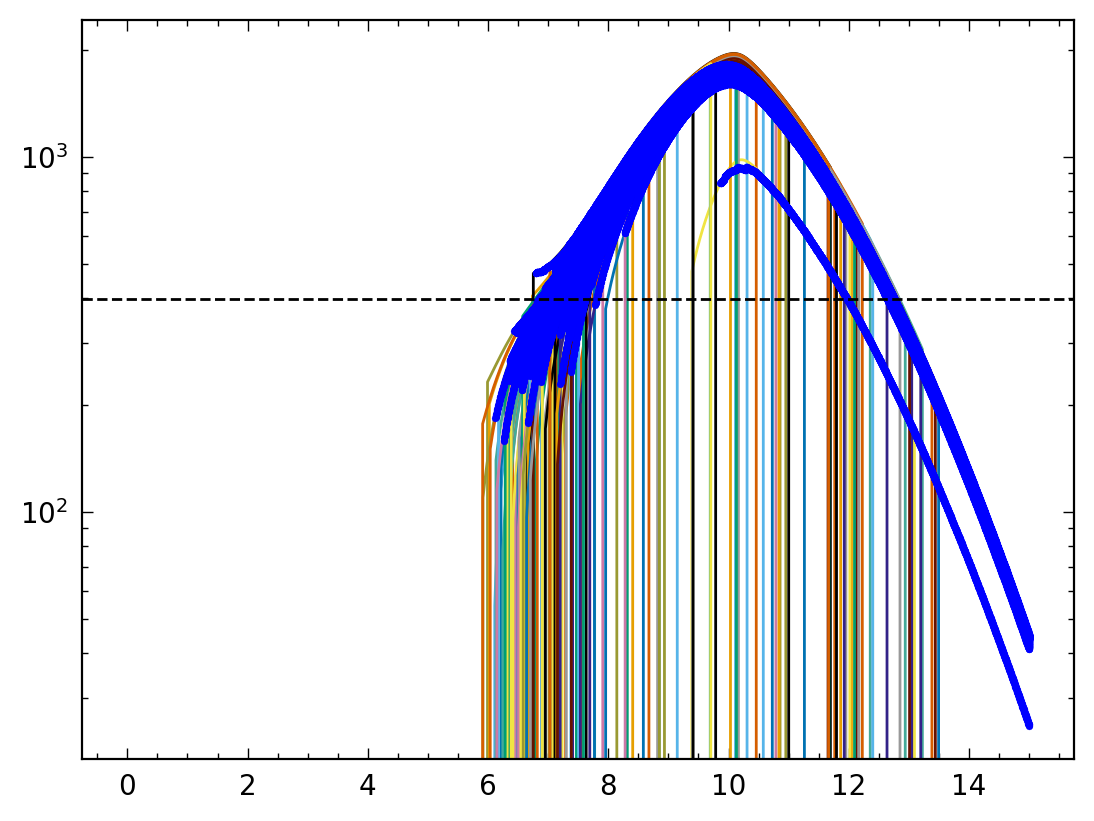

In [6]:
#plt.plot(ts, Eff)
#plt.plot(ts, mycpMa, 'k')
plt.plot(ts, mycEin) #, 'r--')
plt.plot(ts, mycEout, 'b.')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
#plt.plot(ts[0:1000], S[0:1000])
plt.semilogy()
print(np.amax(mycEout))

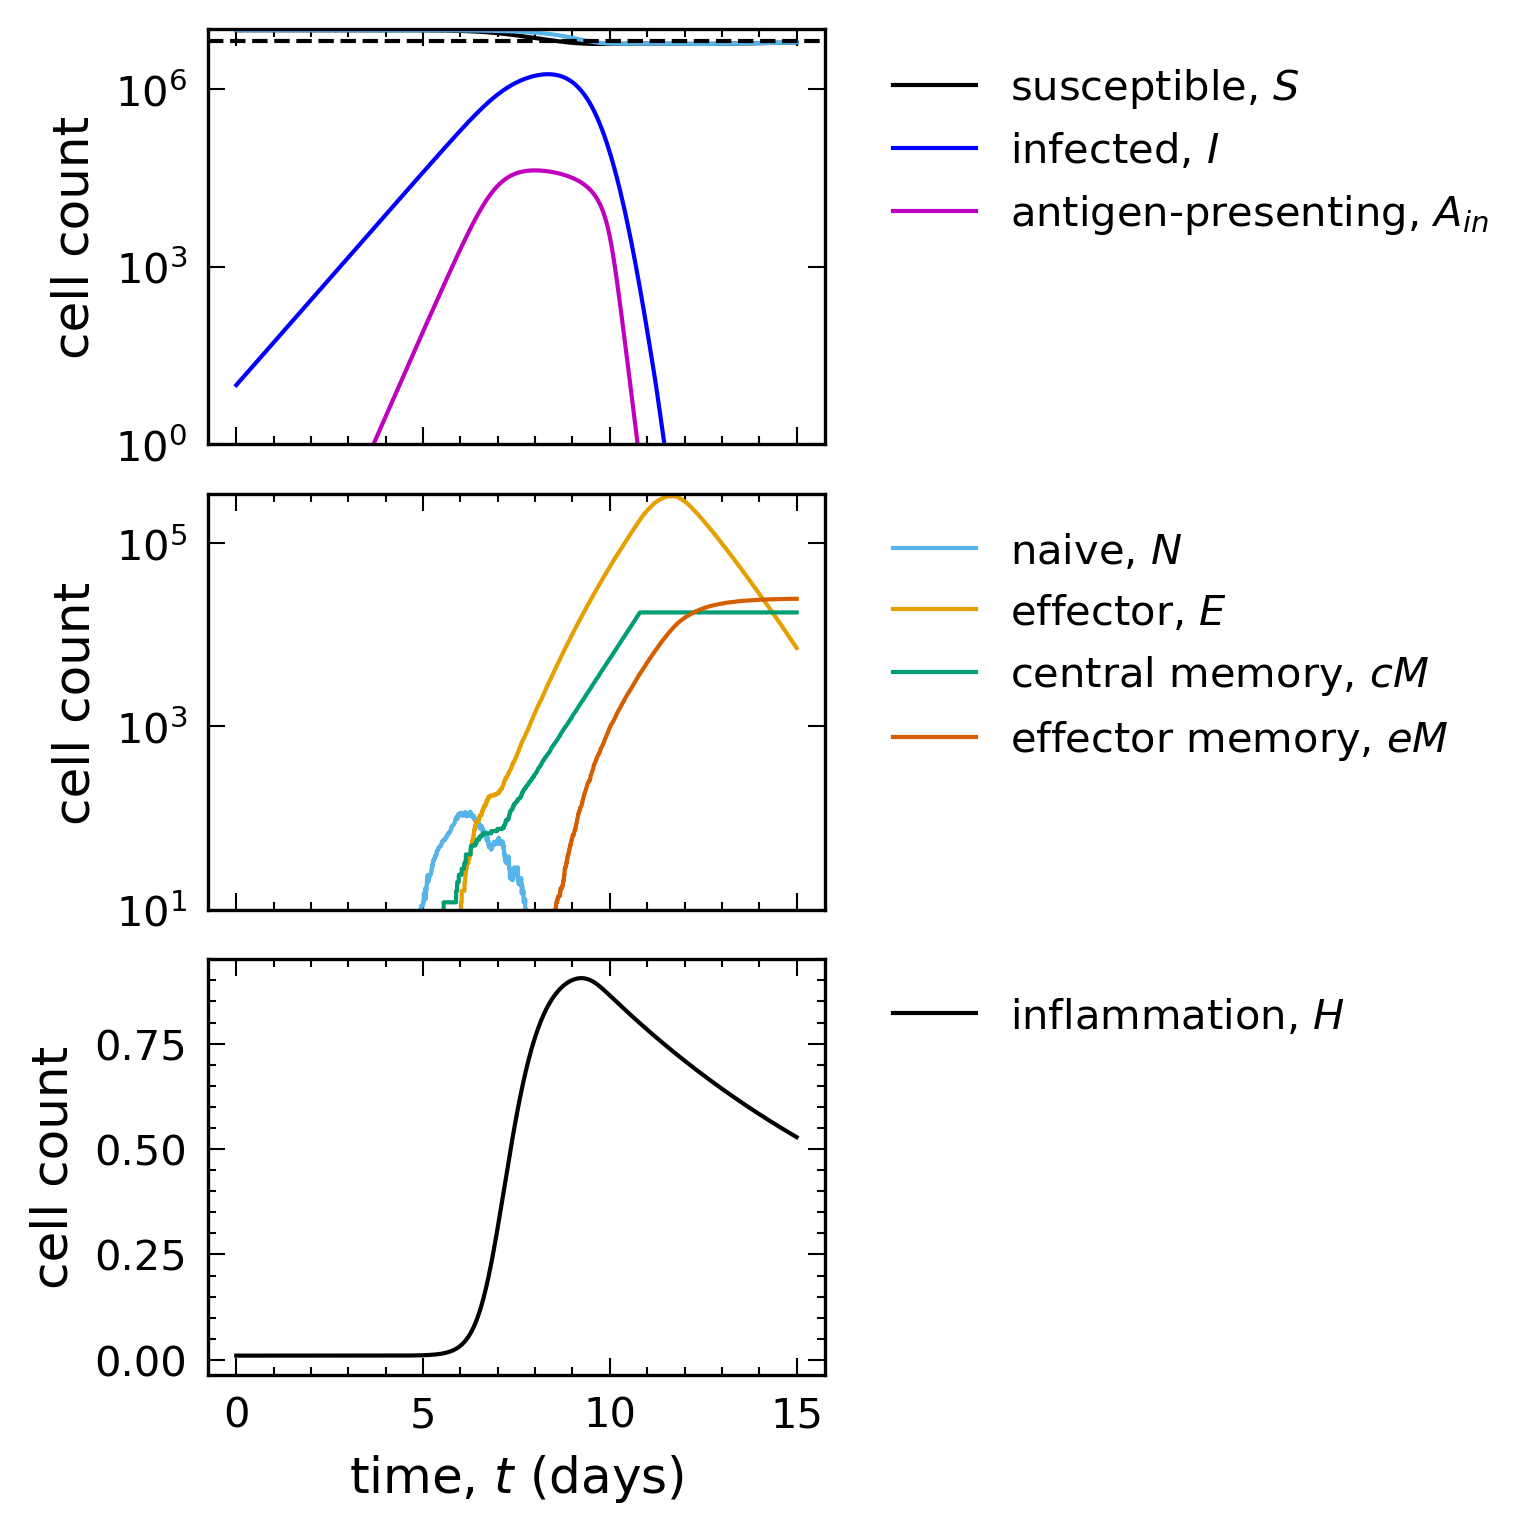

In [12]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, S+I)
ax1.axhline(y = 2/3*S_0, color = 'k', linestyle = '--')
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'naive, $N$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.set(ylabel='cell count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, H,'k-', label = r'inflammation, $H$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='cell count')
#ax3.semilogy()
#ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [8]:
dt = sim_duration/sim_steps

np.array([np.max(I_d_I)/S_0, 
          np.max(I_d_S)/S_0,
          np.argmax(I)*dt,
          np.max(E),
          np.argmax(E)*dt, 
          cM[-1], 
          np.sum(E*dt)/sim_duration, 
          np.log( np.sum(E*dt)/sim_duration ) if np.sum(E*dt) > 0 else 0.0,
          eM[-1],
          (cM[-1] + eM[-1])/np.max(E)])

array([4.58370877e-01, 6.93678434e-02, 8.34300000e+00, 3.27785000e+05,
       1.16400000e+01, 1.76360000e+04, 4.77649372e+04, 1.07740471e+01,
       2.48400000e+04, 1.29584941e-01])

Text(0.5, 0.98, 'Peak response response: $N_0=$ 100, $d_I=$0.5')

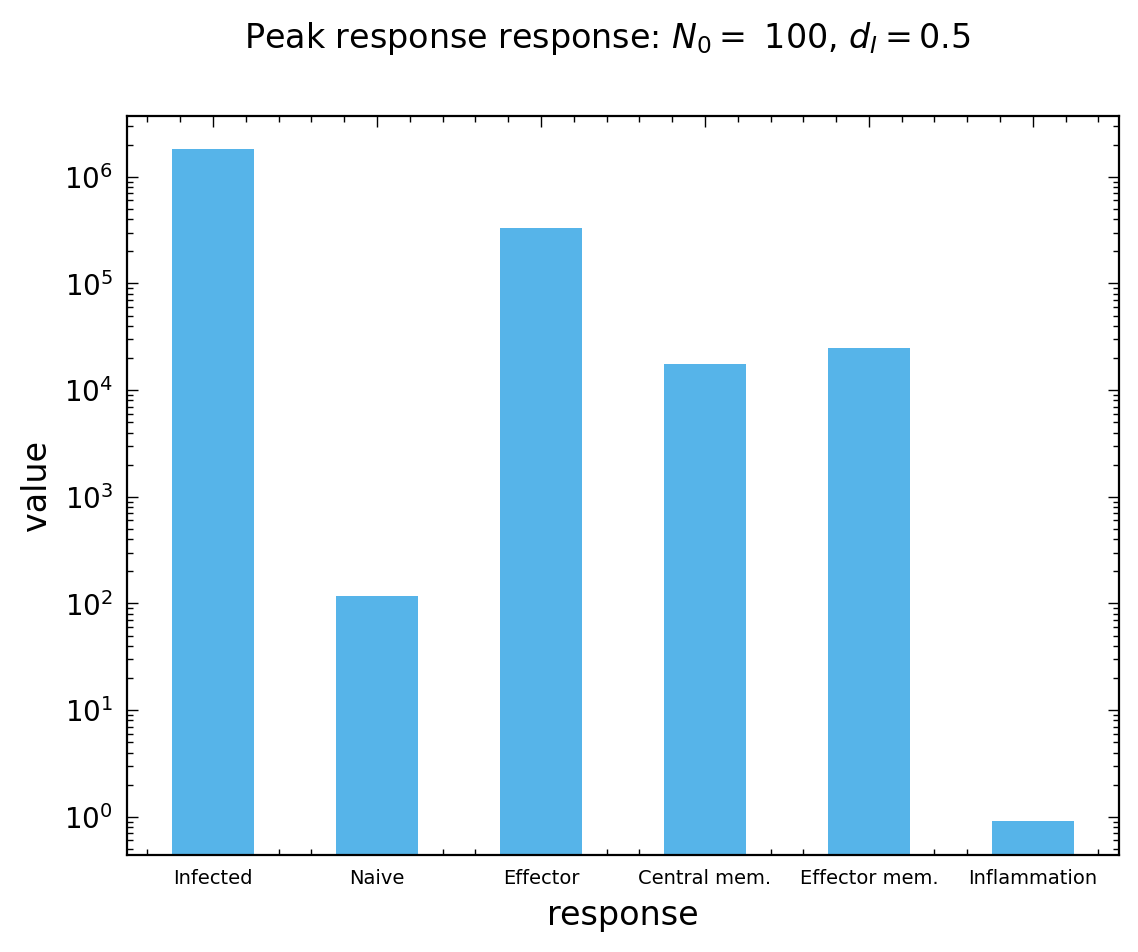

In [9]:
# Compute max values in the data
r = np.arange(6)
width = 0.5
plt.bar(r, np.amax(np.array([I, N, E, cM, eM, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Central mem.","Effector mem.", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

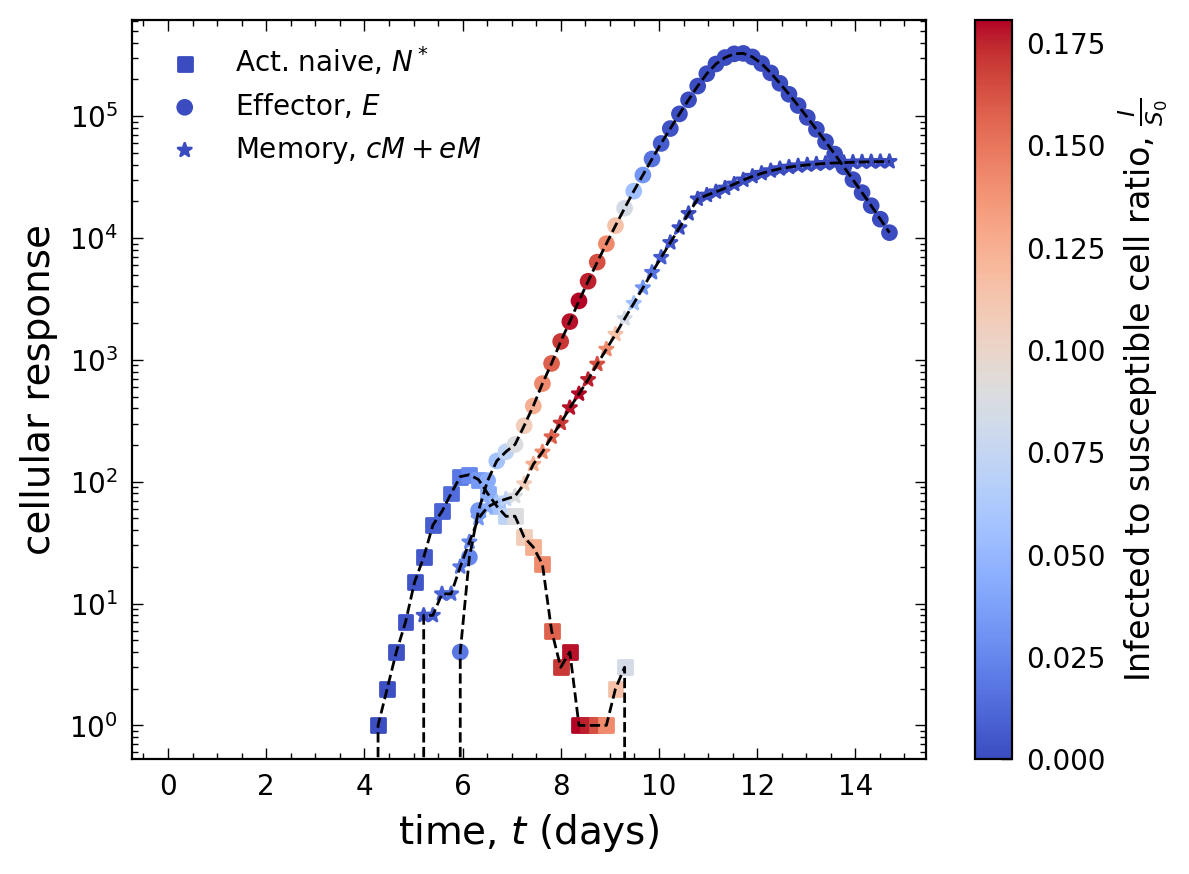

In [10]:
# Plot simulated infection dynamics: pretty plots
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = N[keep]
eff = E[keep]
mem = (cM+eM)[keep]
p_load = I[keep]
time = ts[keep]

plt.scatter(time, naive, marker ='s', c =p_load/S_0, cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
plt.plot(time, naive, 'k--')
plt.scatter(time, eff, marker ='o', c =p_load/S_0, cmap='coolwarm', 
            label = r'Effector, $E$')
plt.plot(time, eff, 'k--')
plt.scatter(time, mem, marker ='*', c =p_load/S_0, cmap='coolwarm',
            label = r'Memory, $cM+eM$')
plt.plot(time, mem, 'k--')

#plt.axvline(x = time[np.argmin(naive[5:]) + 5], color = 'k', linestyle = '--')

#plt.text('$\tau_I=$ '+str(tau_I) +r', $d_I=$'+str(d_I), fontsize=8)
plt.colorbar(label =r"Infected to susceptible cell ratio, $\frac{I}{S_0}$")
plt.ylabel('cellular response', fontsize = 14)
plt.xlabel(r"time, $t$ (days)", fontsize = 14)
plt.semilogy()
plt.legend()

plt.savefig('_figs/'+infection_type+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

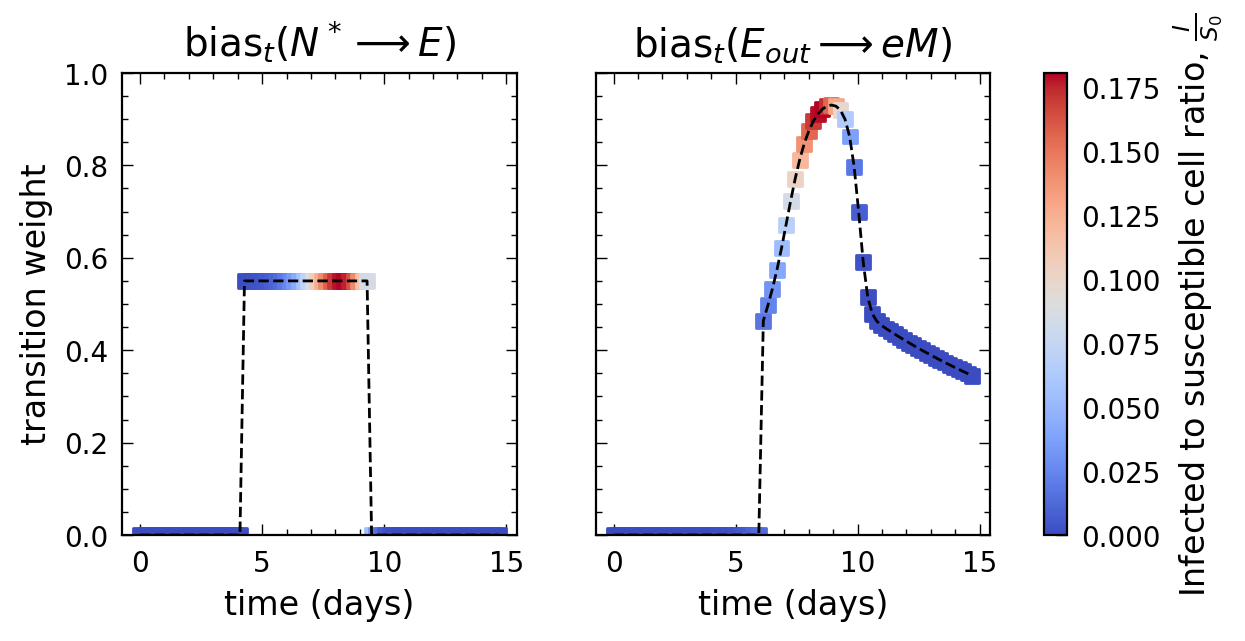

In [11]:
# Plot simulated infection dynamics: pretty plots
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
bias_diff = p_diff[keep]
p_load = I[keep]
sus = S[keep]
time = ts[keep]

fig, axs = plt.subplots(1,2, figsize=(7,3))

if infection_type == "prim":
    im1 = axs[0].scatter(time, bias_diff[:,0], marker = 's', c =p_load/S_0, cmap='coolwarm', 
                label = r'bias$_t(N^* \longrightarrow E)$')
    axs[0].plot(time, bias_diff[:,0],'k--')
    axs[0].title.set_text(r'bias$_t(N^* \longrightarrow E)$')
    axs[0].set_ylim(0,1)
elif infection_type == "sec":
    im1 = axs[0].scatter(time, bias_diff[:,3], marker = 'o', c =p_load/sus, cmap='coolwarm', 
                label = r'$cM$')
    axs[0].scatter(time, bias_diff[:,4], marker = '^', c =p_load/sus, cmap='coolwarm', 
                label = r'$eM$')
    axs[0].plot(time, bias_diff[:,3],'k--')
    axs[0].plot(time, bias_diff[:,4],'k--')
    axs[0].title.set_text(r'bias$_t(pM \longrightarrow E)$')
    axs[0].legend()
    axs[0].set_ylim(0,1)

# if infection_type == "sec":
#     im2 = axs[2].scatter(time, bias_diff[:,3], marker = 'o', c =p_load/sus, cmap='coolwarm', 
#                 label = r'$\mathbb{P}_t(pM \longrightarrow E)$')
#     axs[2].plot(time, bias_diff[:,3],'k--')
#     axs[2].title.set_text(r'$\mathbb{P}_t(pM \longrightarrow E)$')
#     axs[2].set_ylim(0,1)
# else:
#     im2 = axs[2].scatter(time, bias_diff[:,1], marker = '*', c =p_load/sus, cmap='coolwarm', 
#                     label = r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
#     axs[2].plot(time, bias_diff[:,1],'k--')
#     axs[2].title.set_text(r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
#     axs[2].set_ylim(0,1)
    
    
im3 = axs[1].scatter(time, bias_diff[:,2], marker = 's', c =p_load/sus, cmap='coolwarm', 
            label = r'bias$_t(E_{out} \longrightarrow eM)$')
axs[1].plot(time, bias_diff[:,2],'k--')
axs[1].title.set_text(r'bias$_t(E_{out} \longrightarrow eM)$')
axs[1].set_ylim(0,1)

for i, ax in enumerate(axs.flat):
    ax.set(ylabel='transition weight', 
           xlabel="time (days)")

for ax in axs.flat:
    ax.label_outer()

cb = fig.colorbar(im1, ax=axs, orientation='vertical')
cb.set_label(r"Infected to susceptible cell ratio, $\frac{I}{S_0}$")

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_type+'-diff-prob-over-time-harm-'+reg_string+'.png', dpi=300, bbox_inches="tight")